# 🎾 Padel Analytics — Étape 3 : Régression
## Partie D — Prédiction du Prize Money du Gagnant

| | |
|---|---|
| **Objectif** | Prédire le **Prize Money** (`Prize__Winner`) d'un match à partir des caractéristiques du tournoi et des joueurs |
| **Modèles** | Ridge Regression · Random Forest Regressor |
| **Input** | MySQL `dw_padel_analytics` via SQLAlchemy |

---
## 📚 1. Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sqlalchemy import create_engine, text
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats

pd.set_option('display.max_columns', None)
print('✅ Imports OK')

✅ Imports OK


---
## 🔌 2. Connexion MySQL & Chargement

In [5]:
DB_USER, DB_PASSWORD = 'root', ''
DB_HOST, DB_PORT, DB_NAME = '127.0.0.1', '3306', 'dw_padel_analytics'

engine = create_engine(
    f'mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

fact_perf  = pd.read_sql('SELECT * FROM fact_performance', engine)
dim_date   = pd.read_sql('SELECT * FROM dim_date',         engine)
dim_player = pd.read_sql('SELECT * FROM dim_player_ofc',   engine)
dim_gender = pd.read_sql('SELECT * FROM dim_gender',       engine)
dim_type   = pd.read_sql('SELECT * FROM dim_type_match',   engine)
dim_tourn  = pd.read_sql('SELECT * FROM dim_tournmant',    engine)

print(f'✅ fact_performance : {fact_perf.shape}')

✅ fact_performance : (1538, 22)


---
## 🏗️ 3. Préparation du Dataset de Régression

In [7]:
df = fact_perf.copy()

# Convertir Prize__Winner en numérique (certaines valeurs sont '0' ou '268.75')
df['Prize__Winner'] = pd.to_numeric(df['Prize__Winner'], errors='coerce')

# Supprimer les lignes où le prize est 0 ou manquant (matchs sans prize enregistré)
df = df[df['Prize__Winner'] > 0].copy()
print(f'Lignes après filtre prize > 0 : {len(df)}')

# Jointures
df = df.merge(dim_date[['DateKey','Year','Month','Quarter','IsWeekend']], on='DateKey', how='left')
df = df.merge(dim_gender, on='Id_gender', how='left')
df = df.merge(dim_type, on='Id_type_match', how='left')

# Jointure joueur gagnant
p1w = dim_player.rename(columns={
    'Id_Player':'Id_Player_1_winner','Points':'Points_W1','Position':'Position_W1','Level':'Level_W1'
})
df = df.merge(p1w[['Id_Player_1_winner','Points_W1','Position_W1','Level_W1']], on='Id_Player_1_winner', how='left')

# Feature engineering
df['nb_sets']      = df['Score'].apply(lambda x: len(str(x).split()) if pd.notnull(x) else np.nan)
df['points_diff']  = df['Points__Winner'] - df['Points__Loser']
df['is_3sets']     = (df['nb_sets'] == 3).astype(int)

# Sélection des features de régression
reg_features = ['Points__Winner', 'Points__Loser', 'Points_W1', 'Position_W1',
                'points_diff', 'nb_sets', 'is_3sets',
                'Year', 'Month', 'Quarter', 'IsWeekend',
                'Gender', 'Match_type', 'Level_W1']
reg_features = [f for f in reg_features if f in df.columns]

target_col = 'Prize__Winner'
reg_df = df[reg_features + [target_col]].dropna()

print(f'\nDataset de régression : {reg_df.shape}')
print(f'Target (Prize__Winner) — stats :')
print(reg_df[target_col].describe())

Lignes après filtre prize > 0 : 829

Dataset de régression : (488, 15)
Target (Prize__Winner) — stats :
count      488.000000
mean      3579.255123
std       3307.827674
min        100.000000
25%       1128.750000
50%       2642.000000
75%       4414.000000
max      29250.000000
Name: Prize__Winner, dtype: float64


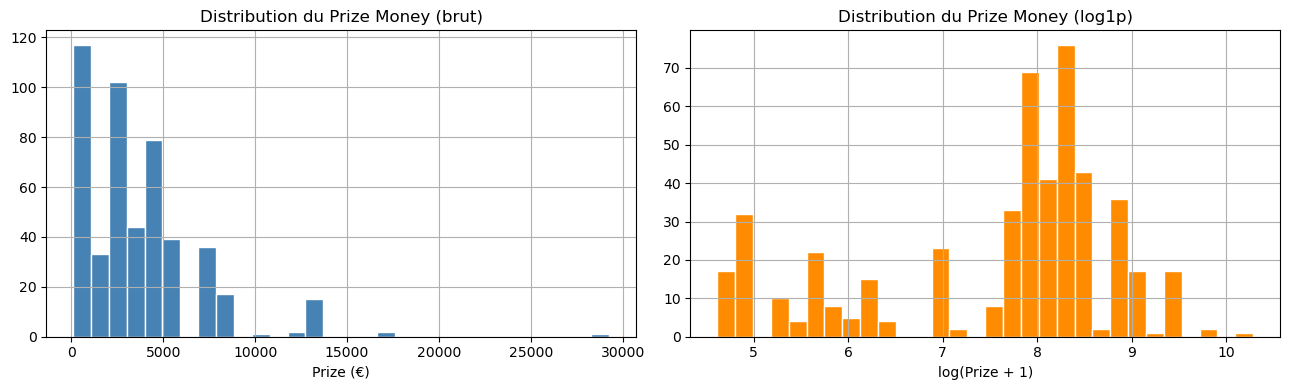

✅ Transformation log1p appliquée sur la target.


In [8]:
# Distribution de la variable cible
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

reg_df[target_col].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribution du Prize Money (brut)', fontsize=12)
axes[0].set_xlabel('Prize (€)')

np.log1p(reg_df[target_col]).hist(bins=30, ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Distribution du Prize Money (log1p)', fontsize=12)
axes[1].set_xlabel('log(Prize + 1)')

plt.tight_layout()
plt.show()

# Appliquer la transformation log pour normaliser
reg_df = reg_df.copy()
reg_df['prize_log'] = np.log1p(reg_df[target_col])
print('✅ Transformation log1p appliquée sur la target.')

In [9]:
# Encodage et préparation finale
X_reg = reg_df[reg_features].copy()
y_reg = reg_df['prize_log']

le = LabelEncoder()
for col in X_reg.select_dtypes(include='object').columns:
    X_reg[col] = le.fit_transform(X_reg[col].astype(str))

# Imputation
imputer = SimpleImputer(strategy='median')
X_reg = pd.DataFrame(imputer.fit_transform(X_reg), columns=X_reg.columns)

X_tr, X_te, y_tr, y_te = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
print(f'Train : {X_tr.shape} | Test : {X_te.shape}')

Train : (390, 14) | Test : (98, 14)


---
## 🧠 D — Compréhension des Modèles

### Régression Ridge
**Intuition :** Régression linéaire avec pénalisation L2 pour éviter le sur-apprentissage.  


---
## 🔧 D.1 — Pipeline Ridge + GridSearch

In [12]:
pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

param_grid_ridge = {'ridge__alpha': [0.01, 0.1, 1, 10, 50, 100, 500]}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_ridge = GridSearchCV(pipe_ridge, param_grid_ridge,
                          cv=kf, scoring='r2', n_jobs=1, verbose=0)
grid_ridge.fit(X_tr, y_tr)

print(f'✅ Meilleur alpha Ridge : {grid_ridge.best_params_}')
print(f'   R² CV (train)        : {grid_ridge.best_score_:.4f}')

✅ Meilleur alpha Ridge : {'ridge__alpha': 10}
   R² CV (train)        : 0.8213


## 🔧 D.2 — Pipeline Random Forest Regressor + RandomizedSearch

In [14]:
pipe_rfr = Pipeline([
    ('rfr', RandomForestRegressor(random_state=42, n_jobs=1))
])

param_dist_rfr = {
    'rfr__n_estimators'     : [100, 200, 300],
    'rfr__max_depth'        : [None, 5, 10, 20],
    'rfr__min_samples_split': [2, 5, 10],
    'rfr__max_features'     : ['sqrt', 'log2']
}

rand_rfr = RandomizedSearchCV(pipe_rfr, param_dist_rfr,
                              n_iter=20, cv=kf, scoring='r2',
                              n_jobs=1, random_state=42, verbose=0)
rand_rfr.fit(X_tr, y_tr)

print(f'✅ Meilleurs params RF Regressor : {rand_rfr.best_params_}')
print(f'   R² CV (train)                : {rand_rfr.best_score_:.4f}')

✅ Meilleurs params RF Regressor : {'rfr__n_estimators': 100, 'rfr__min_samples_split': 2, 'rfr__max_features': 'log2', 'rfr__max_depth': 10}
   R² CV (train)                : 0.9682


## 📊 D.3 — Métriques de comparaison

In [16]:
def eval_regressor(name, model, Xte, yte):
    y_pred = model.predict(Xte)
    mse  = mean_squared_error(yte, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(yte, y_pred)
    r2   = r2_score(yte, y_pred)
    return {'Model': name, 'MSE': round(mse,4), 'RMSE': round(rmse,4),
            'MAE': round(mae,4), 'R²': round(r2,4)}, y_pred

res_ridge, y_pred_ridge = eval_regressor('Ridge Regression',        grid_ridge.best_estimator_, X_te, y_te)
res_rfr,   y_pred_rfr   = eval_regressor('Random Forest Regressor', rand_rfr.best_estimator_,   X_te, y_te)

reg_results = pd.DataFrame([res_ridge, res_rfr]).set_index('Model')
print('📊 COMPARAISON DES MODÈLES DE RÉGRESSION')
display(reg_results.style.highlight_max(subset=['R²'], color='lightgreen')
                         .highlight_min(subset=['MSE','RMSE','MAE'], color='lightgreen'))

📊 COMPARAISON DES MODÈLES DE RÉGRESSION


,MSE,RMSE,MAE,R²
Model,,,,
Ridge Regression,0.208600,0.456700,0.308400,0.861000
Random Forest Regressor,0.017600,0.132700,0.070900,0.988300


## 📈 D.4 — Visualisations : Actual vs Predicted & Résidus

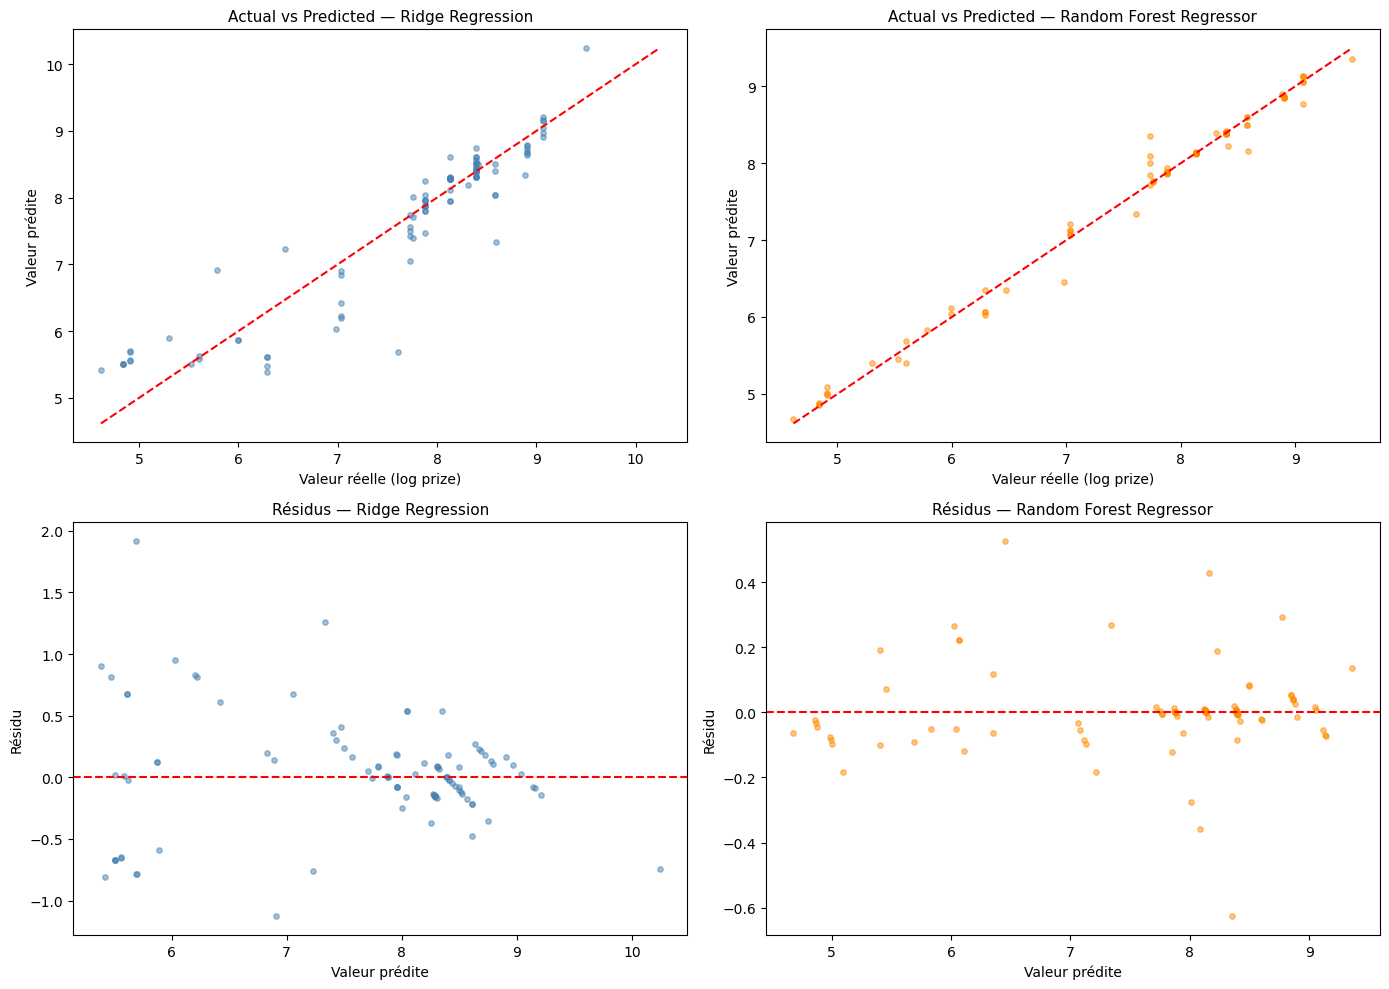

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models_reg = [
    ('Ridge Regression',        y_pred_ridge, 'steelblue'),
    ('Random Forest Regressor', y_pred_rfr,   'darkorange')
]

for col, (name, y_pred, color) in enumerate(models_reg):
    residuals = y_te.values - y_pred

    # Actual vs Predicted
    axes[0, col].scatter(y_te, y_pred, alpha=0.5, color=color, s=15)
    mn, mx = min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())
    axes[0, col].plot([mn, mx], [mn, mx], 'r--', lw=1.5)
    axes[0, col].set_title(f'Actual vs Predicted — {name}', fontsize=11)
    axes[0, col].set_xlabel('Valeur réelle (log prize)')
    axes[0, col].set_ylabel('Valeur prédite')

    # Résidus
    axes[1, col].scatter(y_pred, residuals, alpha=0.5, color=color, s=15)
    axes[1, col].axhline(0, color='red', lw=1.5, linestyle='--')
    axes[1, col].set_title(f'Résidus — {name}', fontsize=11)
    axes[1, col].set_xlabel('Valeur prédite')
    axes[1, col].set_ylabel('Résidu')

plt.tight_layout()
plt.show()

## 📐 D.5 — Vérification des Hypothèses (Ridge)

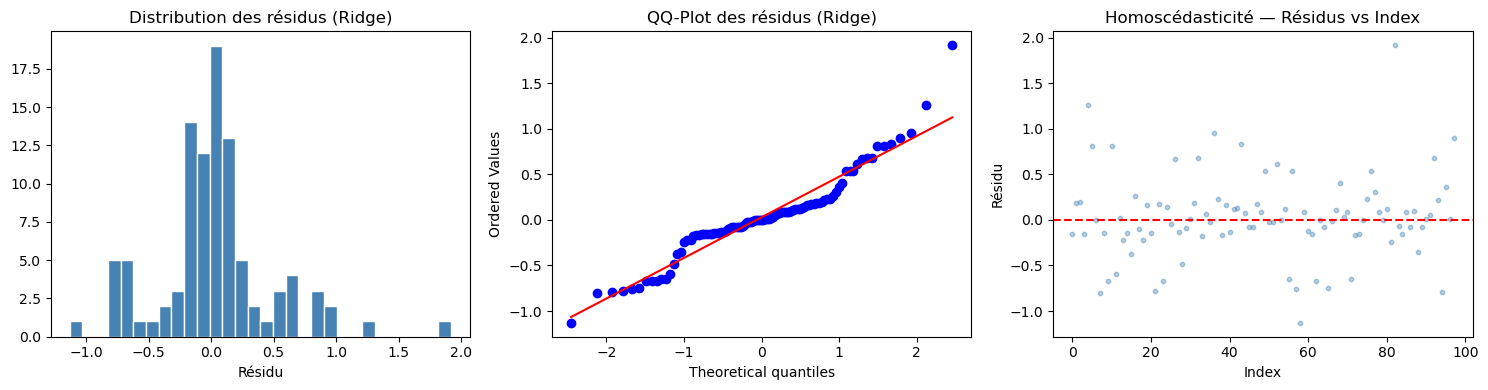

Shapiro-Wilk sur résidus Ridge: stat=0.9281, p=0.0000
→ Résidus non-normaux (p < 0.05)


In [20]:
residuals_ridge = y_te.values - y_pred_ridge

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution des résidus
axes[0].hist(residuals_ridge, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution des résidus (Ridge)')
axes[0].set_xlabel('Résidu')

# QQ-plot normalité
stats.probplot(residuals_ridge, dist='norm', plot=axes[1])
axes[1].set_title('QQ-Plot des résidus (Ridge)')

# Résidus vs index (homoscédasticité)
axes[2].scatter(range(len(residuals_ridge)), residuals_ridge, alpha=0.4, s=10, color='steelblue')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Homoscédasticité — Résidus vs Index')
axes[2].set_xlabel('Index')
axes[2].set_ylabel('Résidu')

plt.tight_layout()
plt.show()

# Test de normalité Shapiro-Wilk
stat, p = stats.shapiro(residuals_ridge[:200])
print(f'Shapiro-Wilk sur résidus Ridge: stat={stat:.4f}, p={p:.4f}')
print('→ Résidus normaux' if p > 0.05 else '→ Résidus non-normaux (p < 0.05)')

## 🌟 D.6 — Feature Importance (RF Regressor)

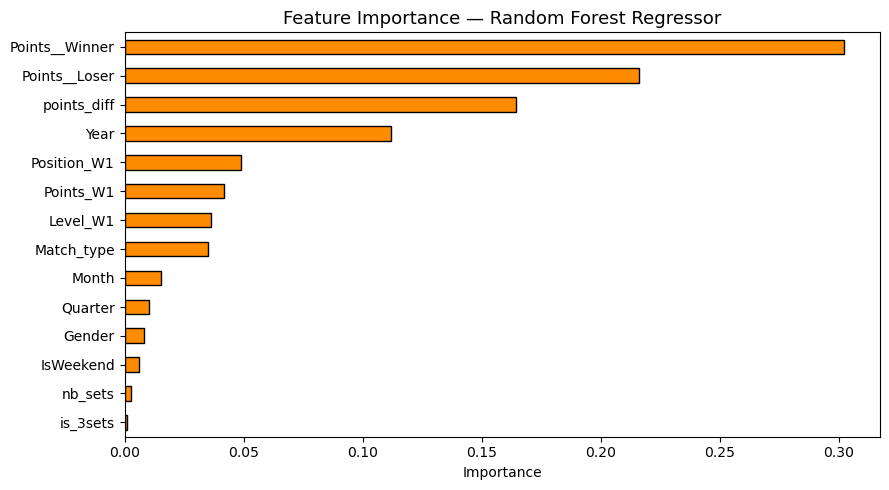


📌 Interprétation :
La feature la plus importante pour prédire le prize money est : Points__Winner
Cela est cohérent car le prize money est directement lié au type de match (phase du tournoi).


In [24]:
rfr_model = rand_rfr.best_estimator_.named_steps['rfr']
feat_imp = pd.Series(rfr_model.feature_importances_, index=X_reg.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
feat_imp.plot(kind='barh', ax=ax, color='darkorange', edgecolor='black')
ax.set_title('Feature Importance — Random Forest Regressor', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('\n📌 Interprétation :')
print(f'La feature la plus importante pour prédire le prize money est : {feat_imp.idxmax()}')
print('Cela est cohérent car le prize money est directement lié au type de match (phase du tournoi).')

## 📋 D.7 — Résumé

In [27]:
print('=' * 60)
print('📋 RÉSUMÉ DE LA RÉGRESSION')
print('=' * 60)
display(reg_results)

best_reg = reg_results['R²'].idxmax()
print(f'\n🏆 Meilleur modèle : {best_reg} (R² = {reg_results.loc[best_reg,"R²"]:.4f})')
print('\n📌 Conclusion :')
print('Le Random Forest Regressor surpasse Ridge car le prize money')
print('ne varie pas linéairement — il dépend fortement du type de match')
print('(phase éliminatoire, demi-finale, finale) qui est une variable catégorielle ordinale.')

📋 RÉSUMÉ DE LA RÉGRESSION


,MSE,RMSE,MAE,R²
Model,,,,
Ridge Regression,0.2086,0.4567,0.3084,0.8610
Random Forest Regressor,0.0176,0.1327,0.0709,0.9883



🏆 Meilleur modèle : Random Forest Regressor (R² = 0.9883)

📌 Conclusion :
Le Random Forest Regressor surpasse Ridge car le prize money
ne varie pas linéairement — il dépend fortement du type de match
(phase éliminatoire, demi-finale, finale) qui est une variable catégorielle ordinale.
